Dataset Source: https://decode.mit.edu/projects/framed

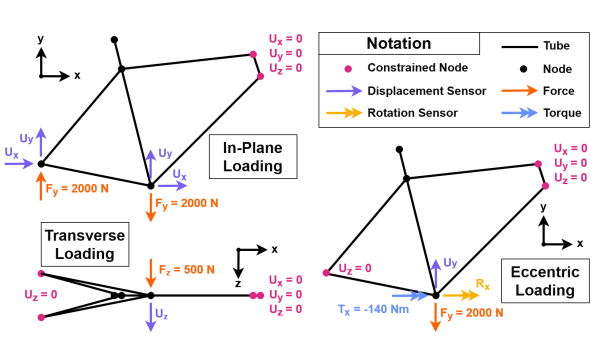

| Parameter | Meaning | Unit / type |
|---|---|---|
| `SSB_Include` | Seat-stay bridge included | Binary (0/1) |
| `CSB_Include` | Chain-stay bridge included | Binary (0/1) |
| `Material` | Frame material | Categorical: Steel / Aluminum / Titanium |
| `CS Length` | Chain-stay length | m |
| `BB Drop` | Bottom-bracket drop | m |
| `Stack` | Frame stack | m |
| `SS E` | Seat-stay junction parameter | m |
| `ST Angle` | Seat-tube angle | deg |
| `BB OD` | Bottom-bracket outer diameter | m |
| `TT OD` | Top-tube outer diameter | m |
| `HT OD` | Head-tube outer diameter | m |
| `DT OD` | Down-tube outer diameter | m |
| `CS OD` | Chain-stay outer diameter | m |
| `SS OD` | Seat-stay outer diameter | m |
| `ST OD` | Seat-tube outer diameter | m |
| `CS F` | Chain-stay position on bottom bracket | m |
| `HT LX` | Head-tube lower extension parameter | m |
| `ST UX` | Seat-tube upper extension parameter | m |
| `HT UX` | Head-tube upper extension parameter | m |
| `HT Angle` | Head-tube angle | deg |
| `HT Length` | Head-tube length | m |
| `ST Length` | Seat-tube length | m |
| `BB Length` | Bottom-bracket shell length | m |
| `Dropout Offset` | Dropout spacing | m |
| `SSB OD` | Seat-stay bridge outer diameter | m |
| `CSB OD` | Chain-stay bridge outer diameter | m |
| `SSB Offset` | Seat-stay bridge position / offset | m |
| `CSB Offset` | Chain-stay bridge position / offset | m |
| `SS Z` | Seat-stay top Z offset | m |
| `SS Thickness` | Seat-stay wall thickness | m |
| `CS Thickness` | Chain-stay wall thickness | m |
| `TT Thickness` | Top-tube wall thickness | m |
| `BB Thickness` | Bottom-bracket wall thickness | m |
| `HT Thickness` | Head-tube wall thickness | m |
| `ST Thickness` | Seat-tube wall thickness | m |
| `DT Thickness` | Down-tube wall thickness | m |
| `DT Length` | Down-tube length | m |

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
structural_data = pd.read_csv("all_structural_data.csv")
print(structural_data.columns.tolist())

In [ ]:
# Hold out rows for extrapolation testing
dataset = structural_data[structural_data["CS OD"] >= 0.02]
held_out = structural_data[structural_data["CS OD"] < 0.02].copy()

In [ ]:
# Pearson correlation matrix
correlation_matrix = dataset.corr(method="pearson", numeric_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.tight_layout()
plt.show()

In [ ]:
sns.histplot(data=dataset, x="Sim 2 Bottom Bracket Z Disp.")
plt.show()

**Random Split**

In [ ]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(dataset, test_size=0.40, random_state=42)
val, test = train_test_split(temp, test_size=0.50, random_state=42)

print(len(train), len(val), len(test)) 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_model(trial, n_features: int) -> keras.Model:
    """Build a configurable regression model for an Optuna trial."""

    inputs = keras.Input(shape=(n_features,), name="features")
    x = inputs

    n_hidden_layers = trial.suggest_int("n_hidden_layers", 1, 5)
    activation = trial.suggest_categorical(
        "activation", ["relu", "elu", "swish"]
    )
    use_batch_norm = trial.suggest_categorical(
        "use_batch_norm", [False, True]
    )

    for layer_index in range(n_hidden_layers):
        units = trial.suggest_int(
            f"units_{layer_index}",
            32,
            512,
            step=32,
        )
        dropout_rate = trial.suggest_float(
            f"dropout_{layer_index}",
            0.0,
            0.5,
            step=0.1,
        )

        x = layers.Dense(
            units,
            kernel_initializer="he_normal",
            name=f"dense_{layer_index}",
        )(x)

        if use_batch_norm:
            x = layers.BatchNormalization(
                name=f"batch_norm_{layer_index}"
            )(x)

        x = layers.Activation(
            activation,
            name=f"activation_{layer_index}",
        )(x)

        if dropout_rate > 0:
            x = layers.Dropout(
                dropout_rate,
                name=f"dropout_{layer_index}",
            )(x)

    outputs = layers.Dense(1, name="prediction")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

    return model

In [ ]:
import optuna
from sklearn.preprocessing import StandardScaler

target = "Sim 2 Bottom Bracket Z Disp."
excluded = {"Unnamed: 0", "Model Mass", "batch"}
features = [
    col for col in train.columns
    if not col.startswith("Sim ") and col not in excluded
]

scaler = StandardScaler()
X_train = scaler.fit_transform(train[features]).astype("float32")
X_val = scaler.transform(val[features]).astype("float32")
y_train = train[target].to_numpy(dtype="float32")
y_val = val[target].to_numpy(dtype="float32")


def objective(trial):
    keras.backend.clear_session()

    model = build_model(trial, n_features=X_train.shape[1])

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=15,
                restore_best_weights=True,
            )
        ],
        verbose=0,
    )

    return min(history.history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best validation MSE:", study.best_value)
print("Best parameters:", study.best_params)

In [ ]:
# Train the best Optuna configuration
keras.backend.clear_session()

best_trial = optuna.trial.FixedTrial(study.best_params)
best_model = build_model(best_trial, n_features=X_train.shape[1])

X_test = scaler.transform(test[features]).astype("float32")
y_test = test[target].to_numpy(dtype="float32")

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
        )
    ],
    verbose=1,
)

# History plot
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Test-set identity plot
y_pred = best_model.predict(X_test, verbose=0).ravel()

limits = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max()),
]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(limits, limits, "k--", label="Ideal")
plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("Actual displacement")
plt.ylabel("Predicted displacement")
plt.title("Test-set identity plot")
plt.legend()
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

test_results = best_model.evaluate(X_test, y_test, verbose=0)
print(dict(zip(best_model.metrics_names, test_results)))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

predictions = {
    "Training": (
        y_train,
        best_model.predict(X_train, verbose=0).ravel(),
    ),
    "Validation": (
        y_val,
        best_model.predict(X_val, verbose=0).ravel(),
    ),
    "Test": (
        y_test,
        best_model.predict(X_test, verbose=0).ravel(),
    ),
}

colors = {
    "Training": "tab:blue",
    "Validation": "tab:orange",
    "Test": "tab:green",
}

all_actual = np.concatenate(
    [actual for actual, _ in predictions.values()]
)
all_predicted = np.concatenate(
    [predicted for _, predicted in predictions.values()]
)

lower = min(all_actual.min(), all_predicted.min())
upper = max(all_actual.max(), all_predicted.max())
padding = 0.05 * (upper - lower)
limits = [lower - padding, upper + padding]

plt.figure(figsize=(7, 7))

for name, (actual, predicted) in predictions.items():
    plt.scatter(
        actual,
        predicted,
        color=colors[name],
        alpha=0.6,
        label=name,
    )

plt.plot(limits, limits, "k--", label="Ideal")
plt.xlim(limits)
plt.ylim(limits)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Actual displacement")
plt.ylabel("Predicted displacement")
plt.title("Actual vs Predicted Displacement")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Identity plot for the initially held-out extrapolation data
X_held_out = scaler.transform(held_out[features]).astype("float32")
y_held_out = held_out[target].to_numpy(dtype="float32")

y_held_out_pred = best_model.predict(
    X_held_out,
    verbose=0,
).ravel()

lower = min(y_held_out.min(), y_held_out_pred.min())
upper = max(y_held_out.max(), y_held_out_pred.max())
padding = 0.05 * (upper - lower)
limits = [lower - padding, upper + padding]

plt.figure(figsize=(7, 7))
plt.scatter(
    y_held_out,
    y_held_out_pred,
    color="tab:red",
    alpha=0.7,
    label="Held-out extrapolation data",
)
plt.plot(limits, limits, "k--", label="Ideal")
plt.xlim(limits)
plt.ylim(limits)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Actual displacement")
plt.ylabel("Predicted displacement")
plt.title("Held-Out Data: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

held_out_results = best_model.evaluate(
    X_held_out,
    y_held_out,
    verbose=0,
    return_dict=True,
)
print(held_out_results)

In [ ]:
# Held-out row with the highest target displacement
highest_index = held_out[target].idxmax()
highest_row = held_out.loc[highest_index]

training_min = train[features].min()
training_max = train[features].max()
training_span = training_max - training_min

comparison = pd.DataFrame({
    "training_min": training_min,
    "training_max": training_max,
    "held_out_value": highest_row[features],
})

# Position relative to the training range: 0 = minimum, 1 = maximum
comparison["relative_position"] = (
    (comparison["held_out_value"] - comparison["training_min"])
    / training_span.replace(0, np.nan)
)

comparison["outside_training_range"] = (
    (comparison["held_out_value"] < comparison["training_min"])
    | (comparison["held_out_value"] > comparison["training_max"])
)

comparison = comparison.sort_values("relative_position")

colors = np.where(
    comparison["outside_training_range"],
    "tab:red",
    "tab:blue",
)

fig, axis = plt.subplots(
    figsize=(10, max(8, 0.32 * len(comparison)))
)

# Every horizontal line represents the training range [0, 1]
axis.hlines(
    y=comparison.index,
    xmin=0,
    xmax=1,
    color="lightgray",
    linewidth=5,
    label="Training range",
)

axis.scatter(
    comparison["relative_position"],
    comparison.index,
    color=colors,
    s=55,
    zorder=3,
)

axis.axvline(0, color="black", linestyle="--", alpha=0.5)
axis.axvline(1, color="black", linestyle="--", alpha=0.5)
axis.set_xlabel("Position relative to training range")
axis.set_ylabel("Input feature")
axis.set_title(
    f"Held-out case with highest displacement\n"
    f"{target} = {highest_row[target]:.6g}"
)
axis.grid(axis="x", alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

display(comparison)

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Uses all rows, including the initially held-out data
n_columns = 4
n_rows = math.ceil(len(features) / n_columns)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(16, 3 * n_rows),
)
axes = axes.ravel()

for axis, feature in zip(axes, features):
    sns.histplot(
        data=structural_data,
        x=feature,
        bins=30,
        ax=axis,
        color="steelblue",
        edgecolor="white",
    )
    axis.axvline(
        structural_data.loc[
            structural_data["CS OD"] >= 0.02,
            feature,
        ].min(),
        color="tab:orange",
        linestyle="--",
        linewidth=1,
    )
    axis.axvline(
        structural_data.loc[
            structural_data["CS OD"] >= 0.02,
            feature,
        ].max(),
        color="tab:orange",
        linestyle="--",
        linewidth=1,
    )
    axis.set_title(feature)
    axis.set_xlabel("")
    axis.set_ylabel("Count")
    axis.grid(axis="y", alpha=0.2)

# Remove unused subplot axes
for axis in axes[len(features):]:
    axis.remove()

fig.suptitle(
    "Input Distributions for the Full Dataset\n"
    "Dashed lines show the training-data range",
    fontsize=16,
    y=1.0,
)
plt.tight_layout()
plt.show()

**Target Extrapolation**

What happens if we use Optuna to optimize for extrapolation?

In [ ]:
# Hold out rows for extrapolation testing
dataset_extrap = structural_data[structural_data["CS OD"] >= 0.03]
val_extrap = structural_data[(structural_data["CS OD"] >= 0.02) & (structural_data["CS OD"] < 0.03)]
held_out = structural_data[structural_data["CS OD"] < 0.02].copy()

In [ ]:
train_extrap, test_extrap = train_test_split(dataset_extrap, test_size=0.20, random_state=42)

In [ ]:
import optuna
from sklearn.preprocessing import StandardScaler

target = "Sim 2 Bottom Bracket Z Disp."
excluded = {"Unnamed: 0", "Model Mass", "batch"}
features = [
    col for col in train_extrap.columns
    if not col.startswith("Sim ") and col not in excluded
]

scaler = StandardScaler()
X_train_e = scaler.fit_transform(train_extrap[features]).astype("float32")
X_val_e = scaler.transform(val_extrap[features]).astype("float32")
y_train_e = train_extrap[target].to_numpy(dtype="float32")
y_val_e = val_extrap[target].to_numpy(dtype="float32")


def objective(trial):
    keras.backend.clear_session()

    model = build_model(trial, n_features=X_train_e.shape[1])

    history = model.fit(
        X_train_e,
        y_train_e,
        validation_data=(X_val_e, y_val_e),
        epochs=100,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=15,
                restore_best_weights=True,
            )
        ],
        verbose=0,
    )

    return min(history.history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best validation MSE:", study.best_value)
print("Best parameters:", study.best_params)

In [ ]:
# Train the best Optuna configuration
keras.backend.clear_session()

best_trial = optuna.trial.FixedTrial(study.best_params)
best_model = build_model(best_trial, n_features=X_train.shape[1])

X_test_e = scaler.transform(test_extrap[features]).astype("float32")
y_test_e = test_extrap[target].to_numpy(dtype="float32")

history = best_model.fit(
    X_train_e,
    y_train_e,
    validation_data=(X_val_e, y_val_e),
    epochs=500,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
        )
    ],
    verbose=1,
)

# History plot
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Test-set identity plot
y_pred_e = best_model.predict(X_test_e, verbose=0).ravel()

limits = [
    min(y_test_e.min(), y_pred_e.min()),
    max(y_test_e.max(), y_pred_e.max()),
]

plt.figure(figsize=(6, 6))
plt.scatter(y_test_e, y_pred_e, alpha=0.6)
plt.plot(limits, limits, "k--", label="Ideal")
plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("Actual displacement")
plt.ylabel("Predicted displacement")
plt.title("Test-set identity plot")
plt.legend()
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

test_results = best_model.evaluate(X_test_e, y_test_e, verbose=0)
print(dict(zip(best_model.metrics_names, test_results)))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

predictions = {
    "Training": (
        y_train_e,
        best_model.predict(X_train_e, verbose=0).ravel(),
    ),
    "Validation": (
        y_val_e,
        best_model.predict(X_val_e, verbose=0).ravel(),
    ),
    "Test": (
        y_test_e,
        best_model.predict(X_test_e, verbose=0).ravel(),
    ),
}

colors = {
    "Training": "tab:blue",
    "Validation": "tab:orange",
    "Test": "tab:green",
}

all_actual = np.concatenate(
    [actual for actual, _ in predictions.values()]
)
all_predicted = np.concatenate(
    [predicted for _, predicted in predictions.values()]
)

lower = min(all_actual.min(), all_predicted.min())
upper = max(all_actual.max(), all_predicted.max())
padding = 0.05 * (upper - lower)
limits = [lower - padding, upper + padding]

plt.figure(figsize=(7, 7))

for name, (actual, predicted) in predictions.items():
    plt.scatter(
        actual,
        predicted,
        color=colors[name],
        alpha=0.6,
        label=name,
    )

plt.plot(limits, limits, "k--", label="Ideal")
plt.xlim(limits)
plt.ylim(limits)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Actual displacement")
plt.ylabel("Predicted displacement")
plt.title("Actual vs Predicted Displacement")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Identity plot for the initially held-out extrapolation data
X_held_out = scaler.transform(held_out[features]).astype("float32")
y_held_out = held_out[target].to_numpy(dtype="float32")

y_held_out_pred = best_model.predict(
    X_held_out,
    verbose=0,
).ravel()

lower = min(y_held_out.min(), y_held_out_pred.min())
upper = max(y_held_out.max(), y_held_out_pred.max())
padding = 0.05 * (upper - lower)
limits = [lower - padding, upper + padding]

plt.figure(figsize=(7, 7))
plt.scatter(
    y_held_out,
    y_held_out_pred,
    color="tab:red",
    alpha=0.7,
    label="Held-out extrapolation data",
)
plt.plot(limits, limits, "k--", label="Ideal")
plt.xlim(limits)
plt.ylim(limits)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Actual displacement")
plt.ylabel("Predicted displacement")
plt.title("Held-Out Data: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

held_out_results = best_model.evaluate(
    X_held_out,
    y_held_out,
    verbose=0,
    return_dict=True,
)
print(held_out_results)

**Takeaway:**

Even though an individual neural networks tries to fit the training data, optuna is prone to finding an architecture that favours fitting the validation data with no regard for the underlying physics.

=> Optuna can overfit on validation

A fully random datasplit still allows for extrapolation beyond the original data, but only within the model envelope

**Steps to make the model engineering ready**

Decide the model scope:
- Either narrow the scope to support only already modeled geometries
- Or extend the scope to support a wider geometry range

If the scope is extended:
- Simulate more geometries close to the desired geometry range
- Consider a more complex model architecture (e.g. physics coupling, multi-stage models)
- Frequently check the model validity with new, unseen data, to prevent and detect accidental leakage
